In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Input/output paths
input_file = '../data/raw/yelp_academic_dataset_review.json'
output_file = '../data/processed/yelp_reviews_sampled_50k.csv'

# Sampling configuration: collect the same number of samples per star rating
target_per_class = 10000
class_counts = {1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0, 5.0: 0}

# Storage for sampled records
sampled_data = []

In [3]:
print("Start loading data ...")

with open(input_file, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        stars = data.get('stars')

        # Keep sampling until each class reaches target_per_class
        if stars in class_counts and class_counts[stars] < target_per_class:
            sampled_data.append({
                'review_id': data.get('review_id'),
                'business_id': data.get('business_id'),
                'stars': stars,
                'text': data.get('text')
            })
            class_counts[stars] += 1

        # Stop early if all classes have enough samples
        if all(count >= target_per_class for count in class_counts.values()):
            print("Sufficient samples have been collected for all star ratings.")
            break

Start loading data ...
Sufficient samples have been collected for all star ratings.


In [4]:
df = pd.DataFrame(sampled_data)
df.to_csv(output_file, index=False, encoding='utf-8')

print(f"Data has been saved to {output_file}.")
print("Distribution of samples across star ratings:")
print(df['stars'].value_counts())

Data has been saved to ../data/processed/yelp_reviews_sampled_50k.csv.
Distribution of samples across star ratings:
stars
3.0    10000
5.0    10000
4.0    10000
1.0    10000
2.0    10000
Name: count, dtype: int64


In [5]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))

    # Count each star rating and sort by rating
    counts = df['stars'].value_counts().sort_index()

    # Draw a bar chart
    bars = plt.bar(
        counts.index.astype(str) + ' Stars',
        counts.values,
        color='skyblue',
        edgecolor='black'
    )

    # Add count labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 100,
            f'{int(yval)}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title('Yelp Review Label Distribution (After Sampling)', fontsize=14)
    plt.xlabel('Star Rating', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.ylim(0, max(counts.values) * 1.15)

    plt.show()

    # Optional: save the figure
    # plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
    # print("Saved figure: class_distribution.png")

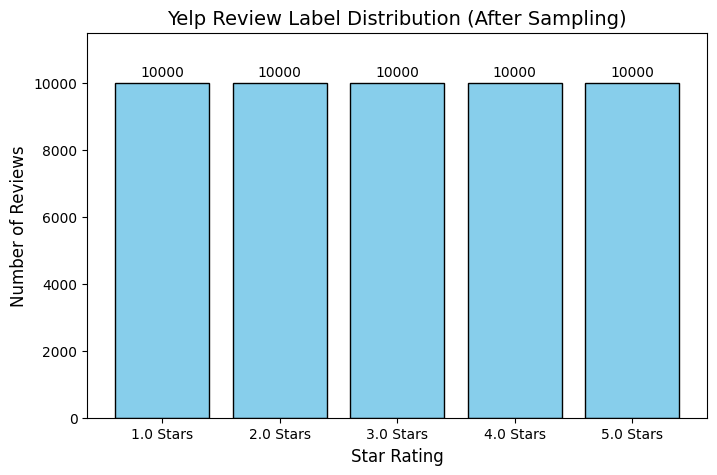

In [6]:
plot_class_distribution(df)